## Increasing Density

In [11]:
import numpy as np
k = 50000
diameter = 500
num_vertices_list = [6, 8, 10, 12]
spacings_list = [0.5*diameter*(np.cos(2*np.pi/m)) for m in num_vertices_list]
force_list = [k/s**3 for s in spacings_list]

grid = np.array([num_vertices_list, spacings_list, force_list]).T

In [ ]:
np.savez("IncDensity/density_list.npz", grid=grid)

## Force-Spacing Grid Search

### Iteration 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

force_array = np.array([1.5, 1.25, 1, 0.725, 0.5, 0.2, 0.06, 0.02])
spacing_array = np.array([500e-3/13, 500e-3/11, 500e-3/9, 500e-3/7, 85e-3, 500e-3/5, 125e-3, 500e-3/3]) # based on length and number of threads

### Iteration 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt

spacing_array = np.linspace(20, 150, 14)
print(spacing_array, len(spacing_array))

force_array = np.array([50e3/i**3 for i in spacing_array])
print(force_array, len(force_array))

[ 20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130. 140. 150.] 14
[6.25       1.85185185 0.78125    0.4        0.23148148 0.14577259
 0.09765625 0.06858711 0.05       0.03756574 0.02893519 0.02275831
 0.01822157 0.01481481] 14


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


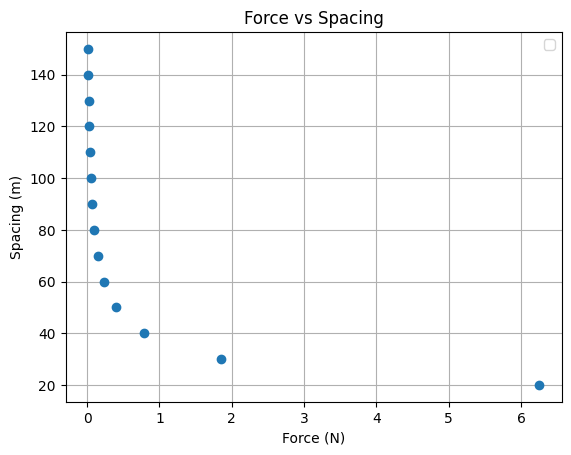

In [4]:
plt.plot(force_array, spacing_array, 'o')
# plt.plot([1.5, 1, 0.5, 0.2, 0.06, 0.02], [500e-3/13, 500e-3/11, 500e-3/9, 500e-3/7, 500e-3/5, 500e-3/3], 's', label='new gs')
# plt.plot([1.5, 1, 0.5, 0.2, 0.06, 0.02], np.linspace(500e-3/13, 500e-3/3, 6), '^', label='old gs')
plt.xlabel('Force (N)')
plt.ylabel('Spacing (m)')
plt.title('Force vs Spacing')
plt.grid()
plt.legend()
plt.show()

In [5]:
force_spacing_list = []
for i in range(len(spacing_array)):
    for j in range(i, len(force_array)):
        force_spacing_list.append((force_array[j], spacing_array[i]))
print(len(force_spacing_list), force_spacing_list)
force_spacing_grid = np.array(force_spacing_list)
print(force_spacing_grid.shape)

extra_force_list = [5, 3.75, 2.5, 1.25]
force_spacing_list.insert(1, (5, spacing_array[0]))
force_spacing_list.insert(2, (3.75, spacing_array[0]))
force_spacing_list.insert(3, (3.75, spacing_array[1]))
force_spacing_list.insert(4, (2.5, spacing_array[0]))
force_spacing_list.insert(5, (2.5, spacing_array[1]))
force_spacing_list.insert(7, (1.25, spacing_array[0]))
force_spacing_list.insert(8, (1.25, spacing_array[1]))
force_spacing_grid = np.array(force_spacing_list)
print(force_spacing_grid.shape)

105 [(6.25, 20.0), (1.8518518518518519, 20.0), (0.78125, 20.0), (0.4, 20.0), (0.23148148148148148, 20.0), (0.1457725947521866, 20.0), (0.09765625, 20.0), (0.06858710562414266, 20.0), (0.05, 20.0), (0.037565740045078885, 20.0), (0.028935185185185185, 20.0), (0.02275830678197542, 20.0), (0.018221574344023325, 20.0), (0.014814814814814815, 20.0), (1.8518518518518519, 30.0), (0.78125, 30.0), (0.4, 30.0), (0.23148148148148148, 30.0), (0.1457725947521866, 30.0), (0.09765625, 30.0), (0.06858710562414266, 30.0), (0.05, 30.0), (0.037565740045078885, 30.0), (0.028935185185185185, 30.0), (0.02275830678197542, 30.0), (0.018221574344023325, 30.0), (0.014814814814814815, 30.0), (0.78125, 40.0), (0.4, 40.0), (0.23148148148148148, 40.0), (0.1457725947521866, 40.0), (0.09765625, 40.0), (0.06858710562414266, 40.0), (0.05, 40.0), (0.037565740045078885, 40.0), (0.028935185185185185, 40.0), (0.02275830678197542, 40.0), (0.018221574344023325, 40.0), (0.014814814814814815, 40.0), (0.4, 50.0), (0.231481481481

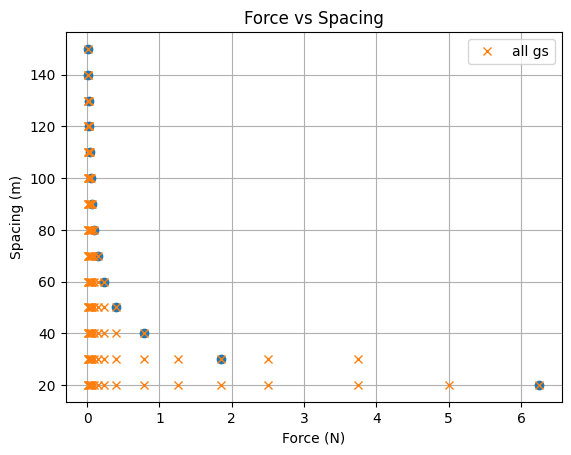

In [6]:
plt.plot(force_array, spacing_array, 'o')
# plt.plot([1.5, 1, 0.5, 0.2, 0.06, 0.02], [500e-3/13, 500e-3/11, 500e-3/9, 500e-3/7, 500e-3/5, 500e-3/3], 's', label='new gs')
# plt.plot([1.5, 1, 0.5, 0.2, 0.06, 0.02], np.linspace(500e-3/13, 500e-3/3, 6), '^', label='old gs')
plt.plot(*zip(*force_spacing_list), 'x', label='all gs')
plt.xlabel('Force (N)')
plt.ylabel('Spacing (m)')
plt.title('Force vs Spacing')
plt.grid()
plt.legend()
plt.show()

In [ ]:
force_spacing_grid[:, 1] = 1e-3*force_spacing_grid[:, 1]
np.savez('GridSearch/ForceSpacing/force_spacing_grid.npz', grid=force_spacing_grid)

In [7]:
force_array_2 = np.hstack([force_array, extra_force_list])
force_array_2 = np.sort(force_array_2)[::-1]
force_array_2

array([6.25      , 5.        , 3.75      , 2.5       , 1.85185185,
       1.25      , 0.78125   , 0.4       , 0.23148148, 0.14577259,
       0.09765625, 0.06858711, 0.05      , 0.03756574, 0.02893519,
       0.02275831, 0.01822157, 0.01481481])

In [8]:
# Create all possible pairs from force_array and spacing_array
all_pairs = np.array([(f, s) for f in force_array_2 for s in spacing_array])

# Find pairs not already in force_spacing_grid
# Use a set for fast lookup
existing_pairs = set(map(tuple, force_spacing_grid))
new_pairs = np.array([pair for pair in all_pairs if tuple(pair) not in existing_pairs])

print(f"Number of new pairs: {len(new_pairs)}")
# print(new_pairs)

Number of new pairs: 140


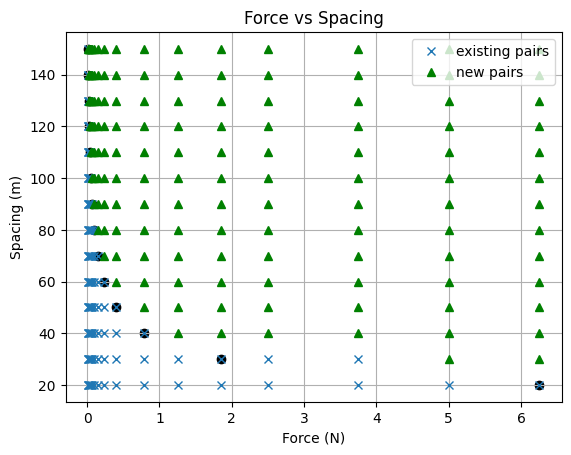

In [9]:
# plt.figure(figsize=(15, 15))
plt.plot(force_array, spacing_array, 'ok', zorder=0)
# plt.plot([1.5, 1, 0.5, 0.2, 0.06, 0.02], [500e-3/13, 500e-3/11, 500e-3/9, 500e-3/7, 500e-3/5, 500e-3/3], 's', label='new gs')
# plt.plot([1.5, 1, 0.5, 0.2, 0.06, 0.02], np.linspace(500e-3/13, 500e-3/3, 6), '^', label='old gs')
plt.plot(*zip(*force_spacing_list), 'x', label='existing pairs')
plt.plot(new_pairs[:, 0], new_pairs[:, 1], '^', color='green', label='new pairs')
plt.xlabel('Force (N)')
plt.ylabel('Spacing (m)')
plt.title('Force vs Spacing')
# plt.ylim(80, 160)
# plt.xlim(0, 0.5)
plt.grid()
plt.legend()
plt.show()

In [ ]:
new_pairs[:, 1] = 1e-3*new_pairs[:, 1]
np.savez('GridSearch/ForceSpacing/force_spacing_grid_2.npz', grid=new_pairs)

## Force Sweep for a Fixed Spacing

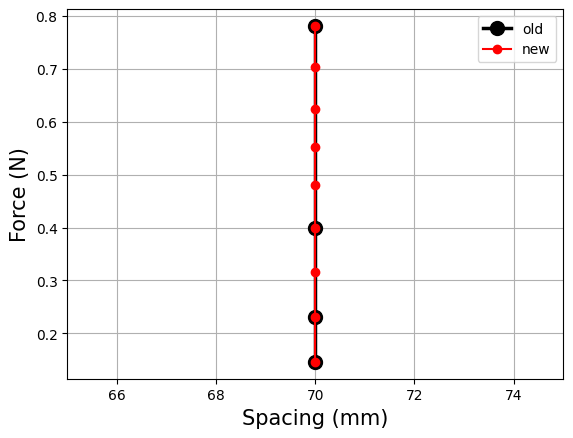

In [10]:
import numpy as np
import matplotlib.pyplot as plt

forces = [0.14577259475218659612316685070254607126116752624512, 0.23148148148148139924273891665507107973098754882812, 0.40000000000000002220446049250313080847263336181641, 0.78125]
spacing_short = [70 for i in range(len(forces))]

forces_new = [forces[0], forces[1], (forces[1]+forces[2])/2, forces[2], 0.48, (0.48+0.625)/2, 0.625, (0.625+forces[3])/2, forces[3]]
spacing_long = [70 for i in range(len(forces_new))]

plt.plot(spacing_short, forces, '-ko', lw=2.5, markersize=10, label='old')
plt.plot(spacing_long, forces_new, '-ro', label='new')
plt.xlabel("Spacing (mm)", fontsize=15)
plt.ylabel("Force (N)", fontsize=15)
plt.xlim([65, 75])
plt.grid()
plt.legend()
plt.show()

In [ ]:
np.savez("GridSearch/ForceSweep/forces_sweep_corrected.npz", sweep=np.array(forces_new))

## Tension-Spacing Grid Search

In [ ]:
import numpy as np

spacing_values = [50, 60, 70, 80, 90, 100]
force_values = [50e3/s**3 for s in spacing_values]

tension_new_values = [1e-2, 1e-1, 5e-1, 1, 2, 5, 10]
new_grid_list = []
for t in tension_new_values:
    for s, f in zip(spacing_values, force_values):
        new_grid_list.append((t, s, f))
new_grid_list

[50, 60, 70, 80, 90, 100]
[0.4, 0.23148148148148148, 0.1457725947521866, 0.09765625, 0.06858710562414266, 0.05]


In [ ]:
new_grid = np.array(new_grid_list)
np.savez("GridSearch/TensionSpacing/tension_spacing_force_grid_new.npz", grid=new_grid)

## Thread-Spacing Grid Search

In [5]:
import numpy as np
import pandas as pd

# Loading Force-Spacing Evaluation Data
GS_data_force_spacing = pd.read_csv('GridSearch/ForceSpacing/GSEvaluation_force_100sec_cap.csv')
spacings = GS_data_force_spacing['spacing(mm)'].unique()
forces = GS_data_force_spacing['force_mag(N)'].unique()

GS_data_force_spacing

,num_threads,spacing(mm),length(mm),force_mag(N),nonlinearity train,memory train,nonlinearity test,memory test
0,4,20.0,100.0,6.250000,0.596823,0.158132,0.568980,0.119997
1,4,20.0,100.0,5.000000,0.571720,0.129950,0.563859,0.100675
2,4,20.0,100.0,3.750000,0.816501,0.151604,0.820762,0.129777
3,4,30.0,150.0,3.750000,0.630659,0.184189,0.621240,0.157294
4,4,20.0,100.0,2.500000,0.782264,0.182670,0.791144,0.160326
...,...,...,...,...,...,...,...,...
247,4,140.0,700.0,0.028935,0.775763,0.264041,0.760747,0.232405
248,4,150.0,750.0,0.028935,0.744774,0.257646,0.728727,0.233609
249,4,140.0,700.0,0.022758,0.776237,0.272875,0.762333,0.235533
250,4,150.0,750.0,0.022758,0.747662,0.264279,0.728930,0.234636


In [6]:
heatmap_data = GS_data_force_spacing.pivot(index='spacing(mm)', columns='force_mag(N)', values='nonlinearity test')
best_nl_list = []
for y, idx in enumerate(heatmap_data.index):
    max_nl_force = GS_data_force_spacing['force_mag(N)'][ (GS_data_force_spacing['spacing(mm)'] == idx) & (GS_data_force_spacing['nonlinearity test'] == heatmap_data.loc[idx].max()) ].values[0]
    best_nl_list.append((idx, max_nl_force))

heatmap_data = GS_data_force_spacing.pivot(index='spacing(mm)', columns='force_mag(N)', values='memory test')
best_mem_list = []
for y, idx in enumerate(heatmap_data.index):
    max_mem_force = GS_data_force_spacing['force_mag(N)'][ (GS_data_force_spacing['spacing(mm)'] == idx) & (GS_data_force_spacing['memory test'] == heatmap_data.loc[idx].max()) ].values[0]
    best_mem_list.append((idx, max_mem_force))

In [ ]:
thread_nos = [2, 4, 6, 8, 10, 12]
best_nl_thread_spacing_list = []
best_mem_thread_spacing_list = []
for tn in thread_nos:
    for s, f in best_nl_list:
        best_nl_thread_spacing_list.append((tn, s*1e-3, f))
    for s, f in best_mem_list:
        best_mem_thread_spacing_list.append((tn, s*1e-3, f))

best_nl_thread_spacing_grid = np.array(best_nl_thread_spacing_list)
best_mem_thread_spacing_grid = np.array(best_mem_thread_spacing_list)
np.savez('thread_spacing_grid_NL.npz', grid=best_nl_thread_spacing_grid)
np.savez('thread_spacing_grid_MC.npz', grid=best_mem_thread_spacing_grid)